In [1]:
import sys
from pathlib import Path

from simulation.simulation import Simulation
import numpy as np

sys.path.append(str(Path.cwd().parent / "bayesian_order_based_learning"))

/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-24 14:30:22,382	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
p = 40
sigma = np.arange(p)

In [3]:
import ray
from tqdm import tqdm

ray.init(ignore_reinit_error=True)

@ray.remote
def run_simulation(sigma, n_k, n_datasets, verbose=False):
    simulation = Simulation(sigma=sigma, n_k=n_k, datasets=n_datasets, verbose=verbose)
    return simulation.simulate()

futures = [run_simulation.remote(sigma, 1000, 1, False) for _ in range(50)]

log_posteriors1 = []
results = []
while futures:
    done, futures = ray.wait(futures)
    results.extend(ray.get(done))

for _, _, result in tqdm(results, desc="Running 50 MCMC chains"):
    log_posteriors1.append(result)

"""
for i in range(50):
    sim = Simulation(sigma=sigma, n_k=1000, datasets=1, verbose=False)
    sim.modify_hyperparameters(T=30000)

    _, _, log_posteriors_i = sim.simulate()
    log_posteriors1.append(log_posteriors_i)
"""

2026-08-24 14:30:26,218	INFO worker.py:2024 -- Started a local Ray instance.


KeyboardInterrupt: 

In [4]:
log_posteriors2 = []
for i in range(5):
    sim = Simulation(sigma=sigma, n_k=200, datasets=5, verbose=True)
    sim.modify_hyperparameters(T=30000)

    _, _, log_posteriors_i = sim.simulate()
    log_posteriors2.append(log_posteriors_i)

2026-08-16 06:44:41,630	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-16 06:44:41,643	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-16 06:44:41,647	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_657919d64db8a03b.zip' (0.01MiB) to Ray cluster...
2026-08-16 06:44:41,648	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_657919d64db8a03b.zip'.
MCMC Sampling wth R2R: 100%|██████████| 30000/30000 [33:11<00:00, 15.06it/s] 
2026-08-16 07:18:03,132	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-16 07:18:03,148	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-16 07:18:03,152	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_657919d64db8a03b.zip' (0.01MiB) to Ray cluster.

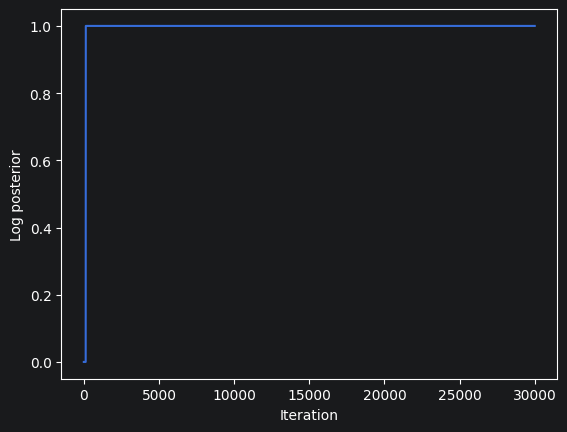

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=range(30001), y=(np.exp(log_posteriors1[0] - np.max(log_posteriors1[0]))))
plt.xlabel("Iteration")
plt.ylabel("Log posterior")
plt.show()

Text(0, 0.5, 'Scaled log posterior')

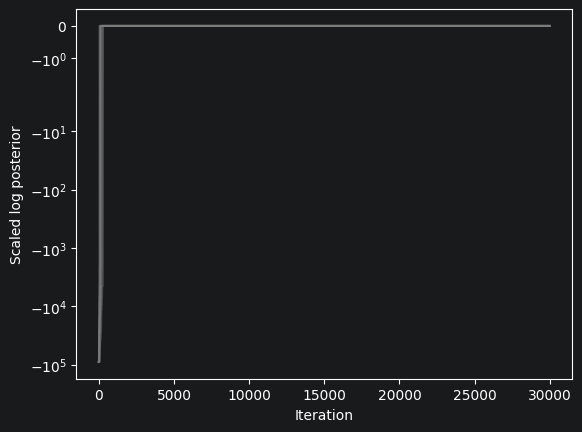

In [6]:
T = 30000

plt.figure()
for log_posteriors_t in log_posteriors1:
    log_posteriors_t = np.array(log_posteriors_t)
    plt.plot(log_posteriors_t - np.max(log_posteriors_t), alpha=0.5, color='gray')

plt.yscale("symlog")
plt.xlabel("Iteration")
plt.ylabel("Scaled log posterior")


Text(0, 0.5, 'Scaled log posterior')

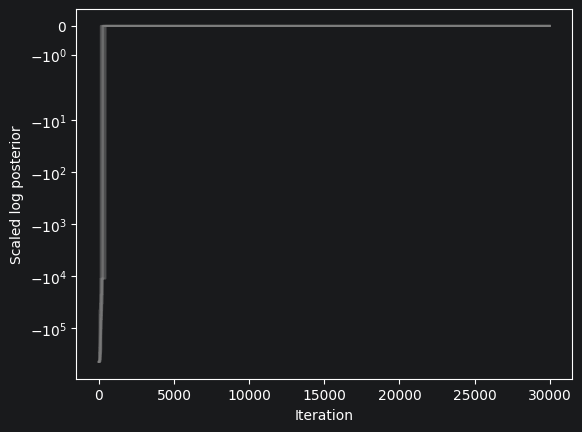

In [7]:
plt.figure()
for log_posteriors_t in log_posteriors2:
    log_posteriors_t = np.array(log_posteriors_t)
    plt.plot(log_posteriors_t - np.max(log_posteriors_t), alpha=0.5, color='gray')

plt.yscale("symlog")
plt.xlabel("Iteration")
plt.ylabel("Scaled log posterior")